# Задача 3. ML / DL и аномалии

- **ML (mlforecast):** LightGBM, RandomForest, Ridge + lag/date/weather features
- **DL (neuralforecast):** NHITS, NBEATS, LSTM
- **Аномалии:** IQR, STL+Z-score, Isolation Forest

**Вывод по задаче 3** — раздел 5 в `README.md`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, RollingMean
from mlforecast.target_transforms import Differences
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, NBEATS, NHITS
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

from src.anomaly import iqr_anomaly_scores, isolation_forest_anomalies, stl_zscore_anomalies
from src.config import FORECAST_HORIZON, SEASON
from src.metrics import evaluate, metrics_table
from src.stats import cv_by_window, cv_summary

H = FORECAST_HORIZON
CV_H = 24
N_WINDOWS = 5
DL_N_WINDOWS = 3
CV_STEP = 24


In [2]:
train_df = pd.read_parquet('__output__/train.parquet')
test_df = pd.read_parquet('__output__/test.parquet')

In [3]:
def df2data(df: pd.DataFrame):
    return pd.DataFrame({
        'unique_id': df['unique_id'].copy(),
        'ds': df.index.values.copy(),
        'y': df['AC_POWER'].copy(),
        'AMBIENT_TEMPERATURE': df['AMBIENT_TEMPERATURE'].copy(),
        'MODULE_TEMPERATURE': df['MODULE_TEMPERATURE'].copy(),
        'IRRADIATION': df['IRRADIATION'].copy(),
    })

In [4]:
train_data = df2data(train_df)
test_data = df2data(test_df)

## 3 метода выявления аномалий

Сравниваем **IQR** (baseline по квантилям), **STL + Z-score** (остатки после декомпозиции, period=24) и **Isolation Forest** (многомерные выбросы по power + weather). Анализ выполняется на train-части Plant 1.

,method,n_anomalies,share_pct
0,IQR,0,0.00
1,STL+Z-score,42,2.73
2,Isolation Forest,31,2.02


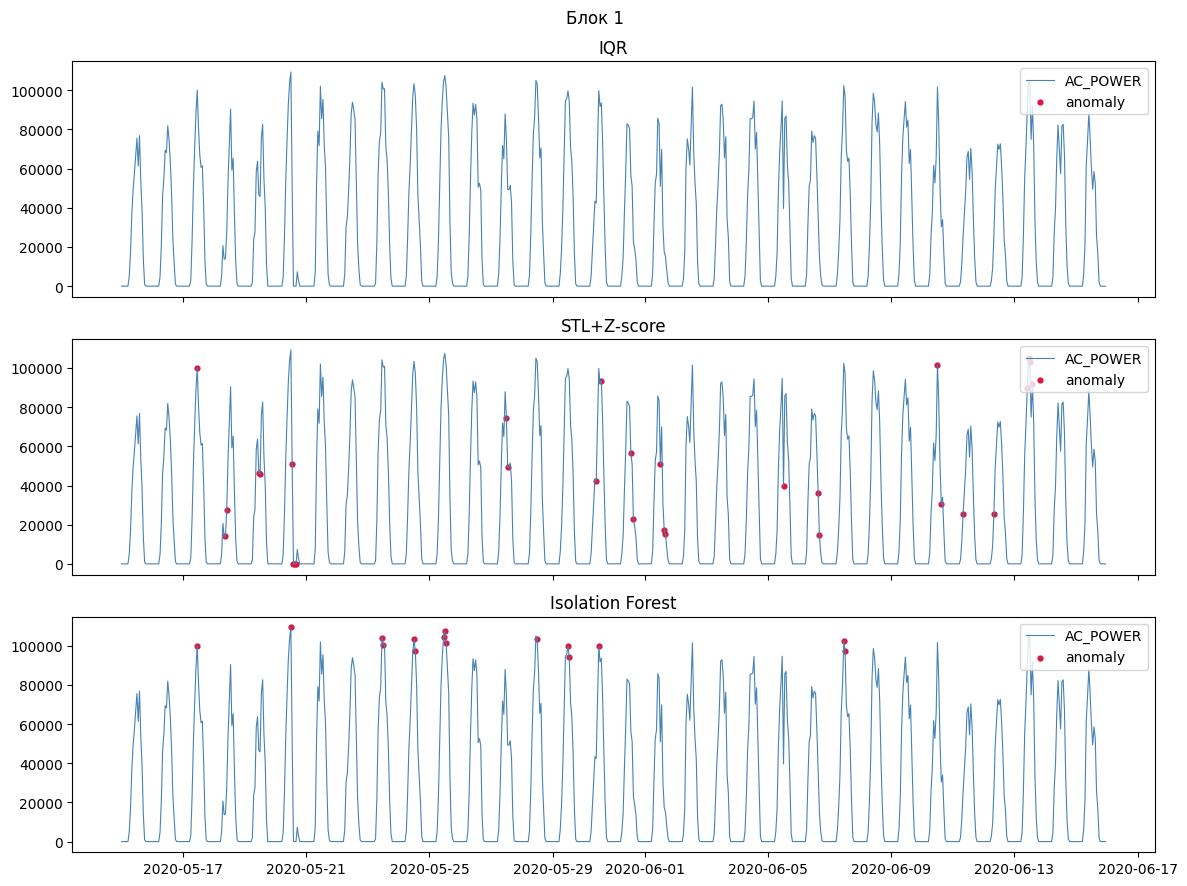

In [5]:
plants = train_df.copy()

iqr_flags = iqr_anomaly_scores(plants['AC_POWER'], k=1.5)
stl_res = stl_zscore_anomalies(plants['AC_POWER'], period=SEASON, z_threshold=3.0)
iso_res = isolation_forest_anomalies(
    plants[[
        'AC_POWER',
        'IRRADIATION',
        'AMBIENT_TEMPERATURE',
        'MODULE_TEMPERATURE'
    ]],
    contamination=0.02,
)

anomaly_df = pd.DataFrame(
    {
        'unique_id': plants['unique_id'],
        'AC_POWER': plants['AC_POWER'],
        'IQR': iqr_flags,
        'STL+Z-score': stl_res['is_anomaly'],
        'IsolationForest': iso_res['is_anomaly'],
    },
    index=train_df.index,
)

anomaly_summary = pd.DataFrame(
    {
        'method': ['IQR', 'STL+Z-score', 'Isolation Forest'],
        'n_anomalies': [
            anomaly_df['IQR'].sum(),
            anomaly_df['STL+Z-score'].sum(),
            anomaly_df['IsolationForest'].sum(),
        ],
    }
)
anomaly_summary['share_pct'] = (
    100 * anomaly_summary['n_anomalies'] / len(anomaly_df)
).round(2)

display(anomaly_summary)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, (method, col) in zip(
    axes,
    [
        ('IQR', 'IQR'),
        ('STL+Z-score', 'STL+Z-score'),
        ('Isolation Forest', 'IsolationForest')
    ],
):
    anomaly_df_uid_1 = anomaly_df[anomaly_df['unique_id'] == '1']
    mask = anomaly_df_uid_1[col]

    ax.plot(
        anomaly_df_uid_1.index,
        anomaly_df_uid_1['AC_POWER'],
        color='steelblue',
        linewidth=0.8,
        label='AC_POWER'
    )
    ax.scatter(
        anomaly_df_uid_1.index[mask],
        anomaly_df_uid_1.loc[mask, 'AC_POWER'],
        color='crimson',
        s=12,
        label='anomaly',
    )
    ax.set_title(method)
    ax.legend(loc='upper right')

plt.suptitle('Блок 1')

plt.tight_layout()
plt.show()

## ML — mlforecast (3 модели)

Lags + погодные признаки + date features. **`Differences([24])` отключён** — на ряду с ~46% нулей (ночь) сезонная разность ухудшает качество.

In [6]:
ml_models = [
    LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    Ridge(alpha=1.0)
]

mlf = MLForecast(
    models=ml_models,
    freq='h',
    lags=[1, 2, 6, 12, 24],
    lag_transforms={
        1: [ExpandingMean()],
        24: [RollingMean(window_size=3)],
    },
    date_features=['hour', 'dayofweek'],
    # target_transforms=[Differences([24])]
)

In [7]:
mlf.fit(train_data, static_features=[])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2581
[LightGBM] [Info] Number of data points in the train set: 1484, number of used features: 12
[LightGBM] [Info] Start training from score 23175.645712


MLForecast(models=[LGBMRegressor, RandomForestRegressor, Ridge], freq=h, lag_features=['lag1', 'lag2', 'lag6', 'lag12', 'lag24', 'expanding_mean_lag1', 'rolling_mean_lag24_window_size3'], date_features=['hour', 'dayofweek'], num_threads=1)

In [8]:
ml_forecasts = mlf.predict(h=H, X_df=test_data)

## DL — neuralforecast (3 модели)

In [9]:
dl_models = [
    NHITS(h=H, input_size=72, max_steps=200),
    NBEATS(h=H, input_size=72, max_steps=200),
    LSTM(h=H, input_size=72, max_steps=200),
]

dlf = NeuralForecast(models=dl_models, freq='h')

Seed set to 1
Seed set to 1
Seed set to 1


In [10]:
dlf.fit(train_data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
0         Non-trainable params
2.6 M     Total params
10.372    Total estimated model params size (MB)
34        

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\GitProjects\TSA\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=200` reached.


In [11]:
dl_forecasts = dlf.predict(h=H, futr_df=test_data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\GitProjects\TSA\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\GitProjects\TSA\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

# Test


In [12]:
def print_metrics(
    data: pd.DataFrame,
    forecast: pd.DataFrame,
    models: list[str],
    no_zeros=False,
):
    data = data.merge(
        forecast,
        on=[
            'unique_id',
            'ds',
        ],
    )

    eval_rows = []
    for m_name in models:
        metrics = evaluate(data['y'], data[m_name], no_zeros)
        metrics['model'] = m_name
        eval_rows.append(metrics)

    results_auto = metrics_table(eval_rows)

    return results_auto


## ML

In [13]:
print_metrics(
    test_data,
    ml_forecasts,
    list(mlf.models.keys()),
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
RandomForestRegressor,1782.791601,4272.714029,6.721515e+00,5.638243
LGBMRegressor,2381.544314,5326.772887,1.438141e+10,99.867061
Ridge,5067.946233,7611.703867,1.043660e+11,107.210537


In [14]:
print_metrics(
    test_data,
    ml_forecasts,
    list(mlf.models.keys()),
    True,
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
RandomForestRegressor,3291.307571,5805.475162,12.408951,10.409063
LGBMRegressor,4131.194236,7229.839214,17.146925,15.139189
Ridge,7429.451881,10000.789970,51.071136,28.696375


## DL

In [15]:
print_metrics(
    test_data,
    dl_forecasts,
    [str(m) for m in dlf.models],
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
NHITS,4994.924683,8997.028728,8.015716e+09,108.940584
LSTM,5687.414354,9980.596802,1.309712e+10,112.503760
NBEATS,5665.445602,10227.011728,1.889406e+10,109.278779


In [16]:
print_metrics(
    test_data,
    dl_forecasts,
    [str(m) for m in dlf.models],
    True,
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
NHITS,9073.416957,12222.915807,44.317134,31.890308
LSTM,10258.048830,13547.822853,69.245565,38.468480
NBEATS,10110.470766,13887.740827,42.668931,32.514669


## Plots

In [17]:
def plot_forecast(
    data: pd.DataFrame,
    forecast: pd.DataFrame,
    models: list[str]
):
    data = data.merge(
        forecast,
        on=[
            'unique_id',
            'ds'
        ]
    )

    fig, axes = plt.subplots(len(models), 1, figsize=(10, 2*len(models)))

    for ax, m_name in zip(axes, models):
        ax.plot(
            data['ds'],
            data['y'],
            label='True'
        )

        ax.plot(
            forecast['ds'],
            forecast[m_name],
            label='Predict'
        )

        ax.legend()
        ax.set_title(f'Model - {m_name}')

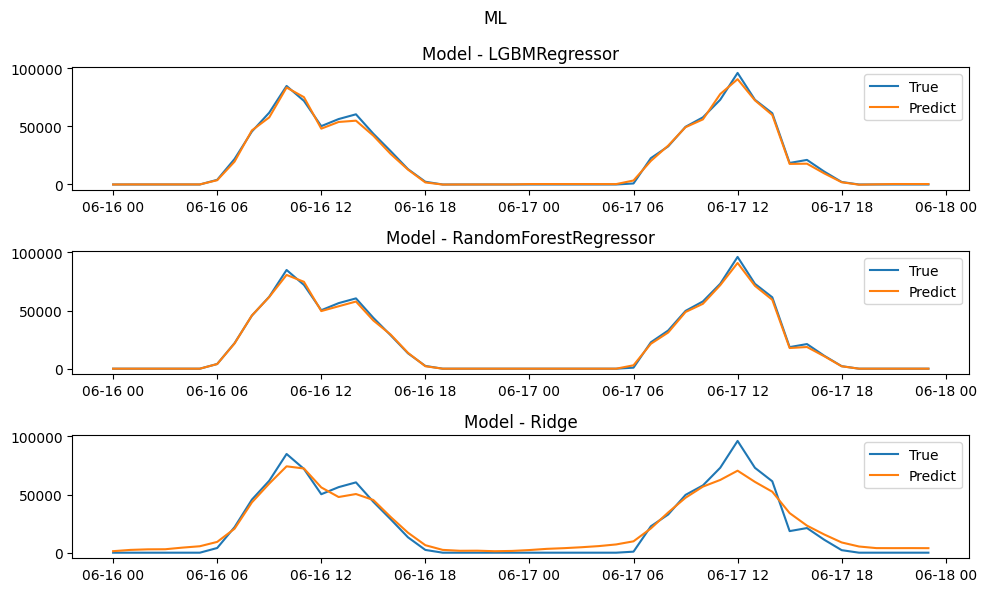

In [18]:
plot_forecast(
    test_data[test_data['unique_id'] == '1'],
    ml_forecasts[ml_forecasts['unique_id'] == '1'],
    list(mlf.models.keys())
)

plt.suptitle('ML')

plt.tight_layout()
plt.show()

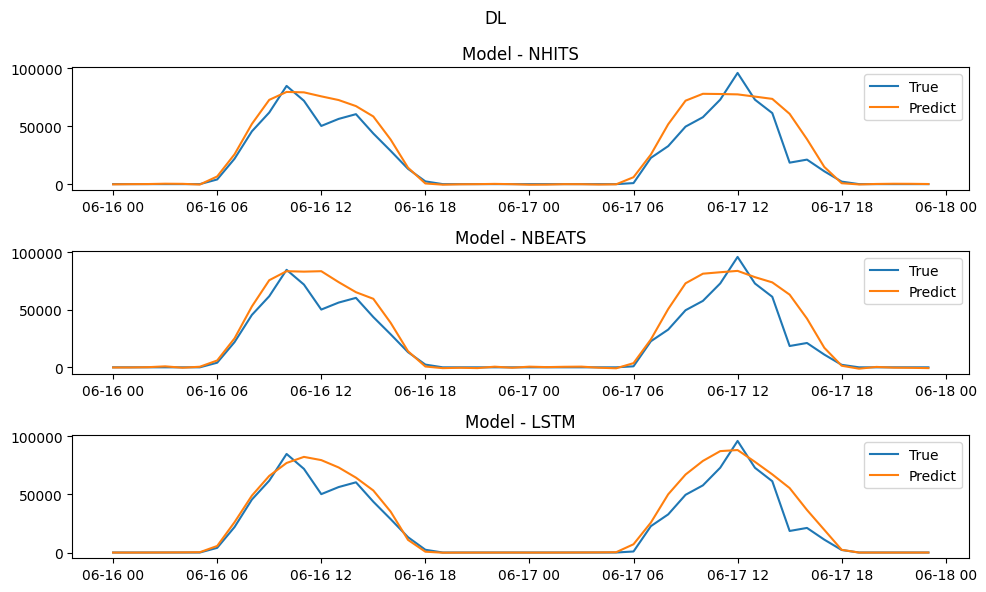

In [19]:
plot_forecast(
    test_data[test_data['unique_id'] == '1'],
    dl_forecasts[dl_forecasts['unique_id'] == '1'],
    [str(m) for m in dlf.models]
)

plt.suptitle('DL')

plt.tight_layout()
plt.show()

## Backtest (ML & DL)

Rolling cross-validation: **h=24 ч**, шаг **24 ч**. ML — 5 окон; DL — 3 окна (медленнее из-за обучения нейросетей).

In [20]:
cv_data = train_data[train_data['unique_id'] == '1']

mlf_cv = MLForecast(
    models=ml_models,
    freq='h',
    lags=[1, 2, 6, 12, 24],
    lag_transforms={
        1: [ExpandingMean()],
        24: [RollingMean(window_size=3)],
    },
    date_features=['hour', 'dayofweek'],
)

In [21]:

print(f'ML cross-validation: h={CV_H}, n_windows={N_WINDOWS}, step={CV_STEP}')
ml_cv = mlf_cv.cross_validation(
    df=cv_data,
    n_windows=N_WINDOWS,
    h=CV_H,
    step_size=CV_STEP,
    static_features=[],
)
ml_cv_names = list(mlf_cv.models.keys())

ML cross-validation: h=24, n_windows=5, step=24
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000277 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1494
[LightGBM] [Info] Number of data points in the train set: 598, number of used features: 12
[LightGBM] [Info] Start training from score -4.050710
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

,MAE,RMSE,MAPE,sMAPE
model,,,,
LGBMRegressor,6782.462416,10292.815391,4.907653e+10,119.752835
RandomForestRegressor,5899.657586,10771.617056,6.369083e+08,29.291948
Ridge,6739.701200,10978.077724,7.388320e+10,111.706823


model,LGBMRegressor,RandomForestRegressor,Ridge
cutoff,,,
2020-06-10 23:00:00,11668.21,12456.47,12031.52
2020-06-11 23:00:00,11078.78,5201.44,4754.38
2020-06-12 23:00:00,8450.94,13013.92,10701.61
2020-06-13 23:00:00,11122.10,10598.27,14407.46
2020-06-14 23:00:00,8700.82,10781.22,10636.27


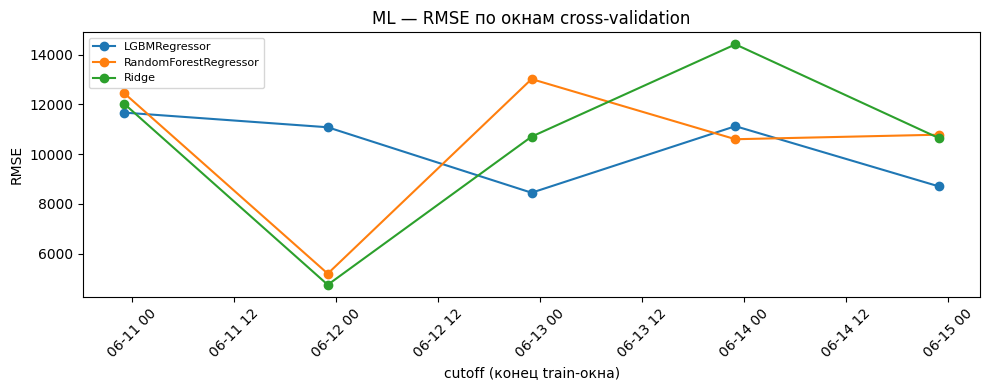

Лучшая ML-модель по backtest: LGBMRegressor


In [22]:
ml_cv_overall = cv_summary(ml_cv, ml_cv_names)
display(ml_cv_overall)

ml_cv_window = cv_by_window(ml_cv, ml_cv_names)
ml_cv_pivot = ml_cv_window.pivot(index='cutoff', columns='model', values='RMSE')
display(ml_cv_pivot.round(2))

fig, ax = plt.subplots(figsize=(10, 4))
for name in ml_cv_names:
    subset = ml_cv_window[ml_cv_window['model'] == name]
    ax.plot(subset['cutoff'], subset['RMSE'], marker='o', label=name)
ax.set_title('ML — RMSE по окнам cross-validation')
ax.set_xlabel('cutoff (конец train-окна)')
ax.set_ylabel('RMSE')
ax.legend(loc='best', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_ml_cv = ml_cv_overall.index[0]
print(f'Лучшая ML-модель по backtest: {best_ml_cv}')

In [23]:
dl_cv_models = [
    NHITS(h=CV_H, input_size=72, max_steps=200),
    NBEATS(h=CV_H, input_size=72, max_steps=200),
    LSTM(h=CV_H, input_size=72, max_steps=200),
]
dl_cv_names = [str(m) for m in dl_cv_models]

dlf_cv = NeuralForecast(models=dl_cv_models, freq='h')

Seed set to 1
Seed set to 1
Seed set to 1


In [24]:

print(f'DL cross-validation: h={CV_H}, n_windows={DL_N_WINDOWS}, step={CV_STEP}')
dl_cv = dlf_cv.cross_validation(
    df=cv_data,
    n_windows=DL_N_WINDOWS,
    step_size=CV_STEP,
    h=CV_H,
    refit=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
0         Non-trainable params
2.6 M     Total params
10.286    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


DL cross-validation: h=24, n_windows=3, step=24


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\GitProjects\TSA\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\GitProjects\TSA\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

,MAE,RMSE,MAPE,sMAPE
model,,,,
NHITS,7292.236199,12941.888592,8.692243e+09,107.478380
NBEATS,8541.706563,14158.950742,2.632444e+10,112.206398
LSTM,8291.339535,15296.604521,1.944663e+09,110.111425


model,LSTM,NBEATS,NHITS
cutoff,,,
2020-06-12 23:00:00,18241.09,15776.32,15675.89
2020-06-13 23:00:00,9501.46,12712.16,11849.47
2020-06-14 23:00:00,16701.59,13817.97,10785.82


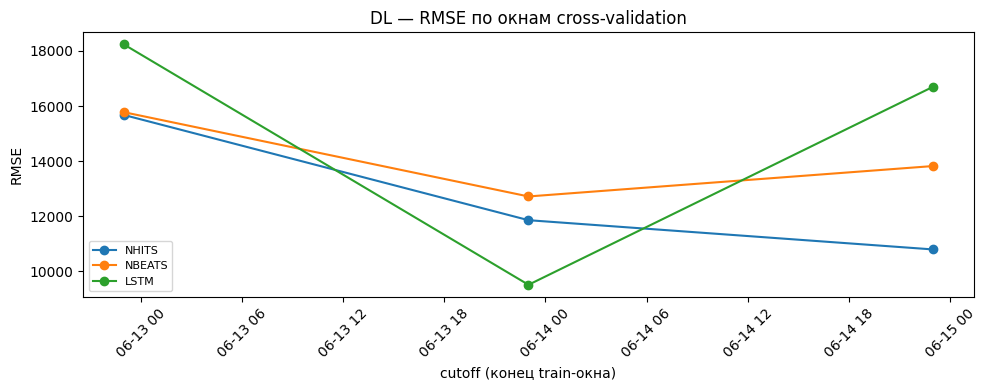

Лучшая DL-модель по backtest: NHITS


In [25]:
dl_cv_overall = cv_summary(dl_cv, dl_cv_names)
display(dl_cv_overall)

dl_cv_window = cv_by_window(dl_cv, dl_cv_names)
dl_cv_pivot = dl_cv_window.pivot(index='cutoff', columns='model', values='RMSE')
display(dl_cv_pivot.round(2))

fig, ax = plt.subplots(figsize=(10, 4))
for name in dl_cv_names:
    subset = dl_cv_window[dl_cv_window['model'] == name]
    ax.plot(subset['cutoff'], subset['RMSE'], marker='o', label=name)
ax.set_title('DL — RMSE по окнам cross-validation')
ax.set_xlabel('cutoff (конец train-окна)')
ax.set_ylabel('RMSE')
ax.legend(loc='best', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_dl_cv = dl_cv_overall.index[0]
print(f'Лучшая DL-модель по backtest: {best_dl_cv}')

## Анализ остатков (ML & DL)

In-sample диагностика для всех ML-моделей (fitted values); out-of-sample остатки из rolling CV для DL. Проверка: ACF, Q–Q, Ljung–Box — как в `1_stats_models.ipynb`.

In [26]:
def plot_residual_diagnostics(
    ds,
    y,
    pred,
    model_name: str,
):
    res = y - pred
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    axes[0, 0].plot(ds, res, linewidth=0.8)
    axes[0, 0].axhline(0, color='k', linewidth=0.5)
    axes[0, 0].set_title(f'Остатки во времени — {model_name}')
    axes[0, 0].set_xlabel('ds')
    axes[0, 0].tick_params(axis='x', rotation=45)

    sns.histplot(res, kde=True, ax=axes[0, 1])
    axes[0, 1].set_title('Распределение остатков')

    plot_acf(res, lags=48, ax=axes[1, 0])
    axes[1, 0].set_title('ACF остатков')

    stats.probplot(res, dist='norm', plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q plot (нормальность)')

    plt.tight_layout()
    plt.show()

    lb = acorr_ljungbox(res, lags=[24, 48], return_df=True)
    print(f'Ljung–Box ({model_name}):')
    display(lb)


ml_holdout = print_metrics(test_data, ml_forecasts, list(mlf.models.keys()))
best_ml_name = ml_holdout.index[0]
print(f'Лучшая ML-модель на hold-out: {best_ml_name}')

residual_data = cv_data.copy()
mlf_res = MLForecast(
    models=ml_models,
    freq='h',
    lags=[1, 2, 6, 12, 24],
    lag_transforms={1: [ExpandingMean()], 24: [RollingMean(window_size=3)]},
    date_features=['hour', 'dayofweek'],
)
mlf_res.fit(residual_data, static_features=[], fitted=True)
ml_fitted = mlf_res.forecast_fitted_values()

Лучшая ML-модель на hold-out: RandomForestRegressor
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1780
[LightGBM] [Info] Number of data points in the train set: 718, number of used features: 12
[LightGBM] [Info] Start training from score 33.598954
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

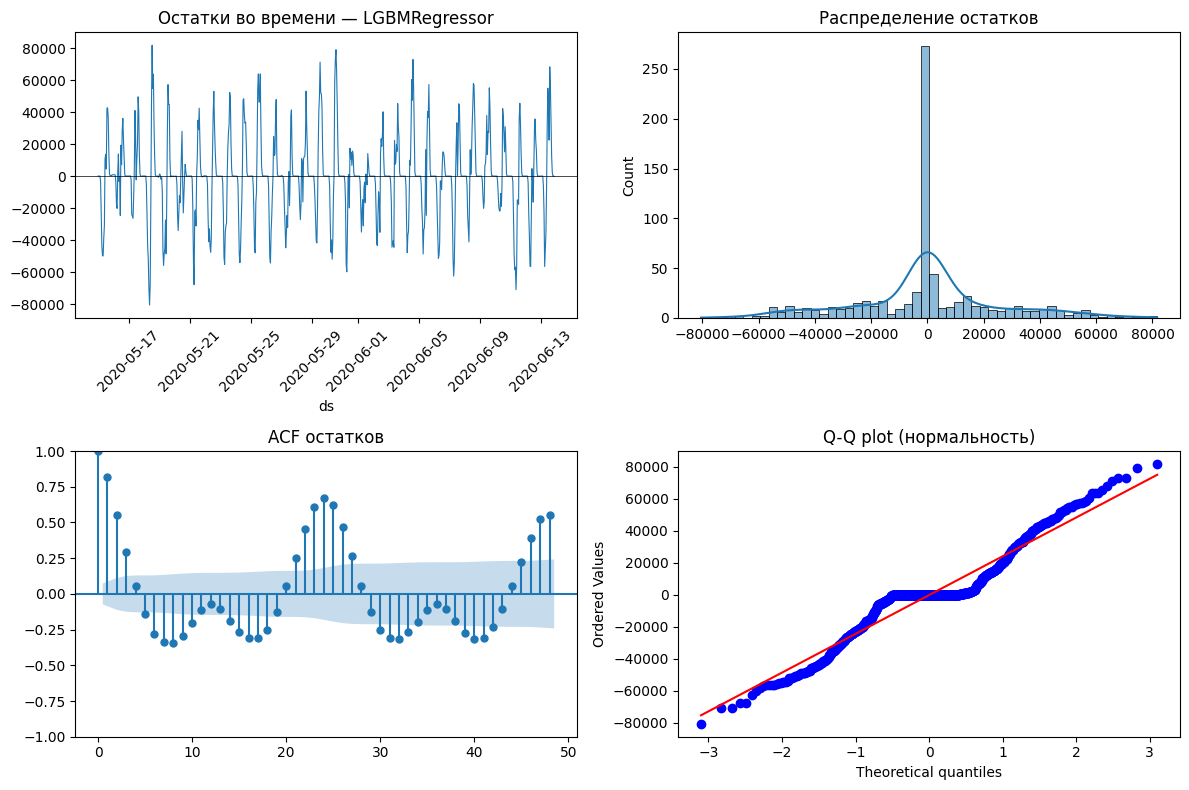

Ljung–Box (LGBMRegressor):


,lb_stat,lb_pvalue
24,2212.750539,0.0
48,3913.324555,0.0


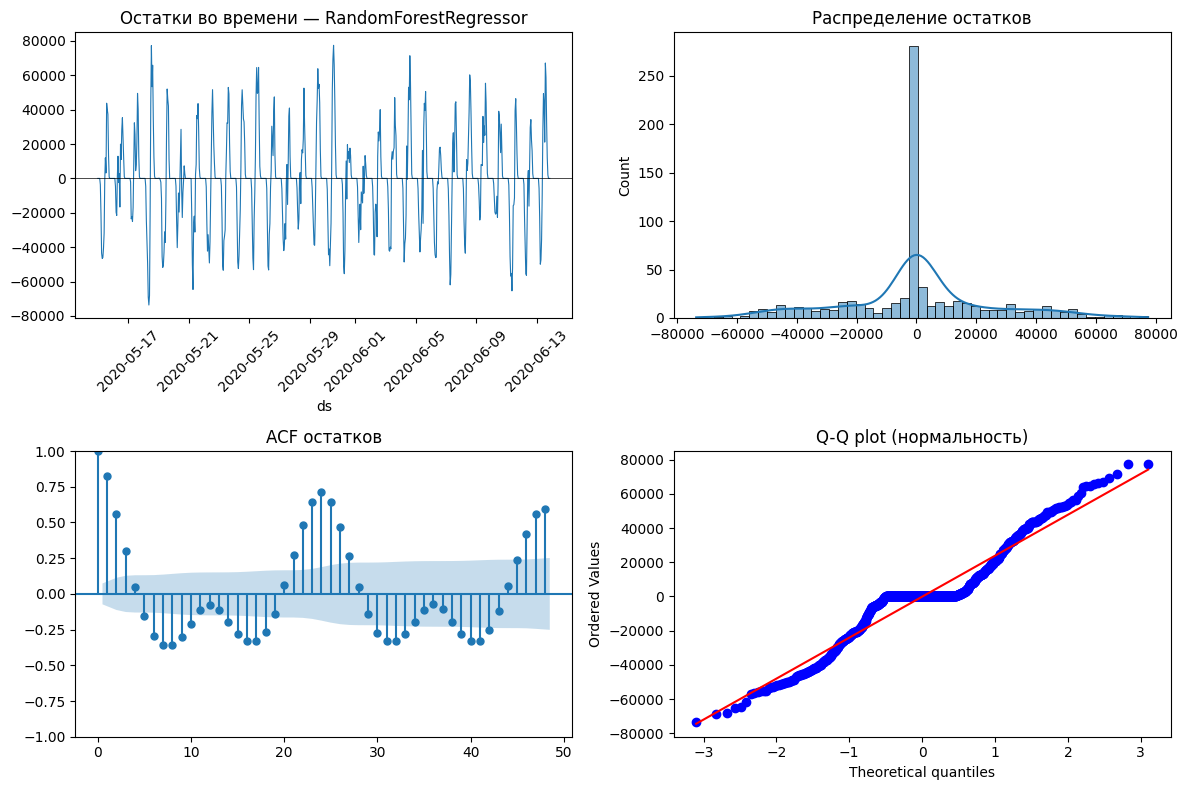

Ljung–Box (RandomForestRegressor):


,lb_stat,lb_pvalue
24,2404.278817,0.0
48,4290.175732,0.0


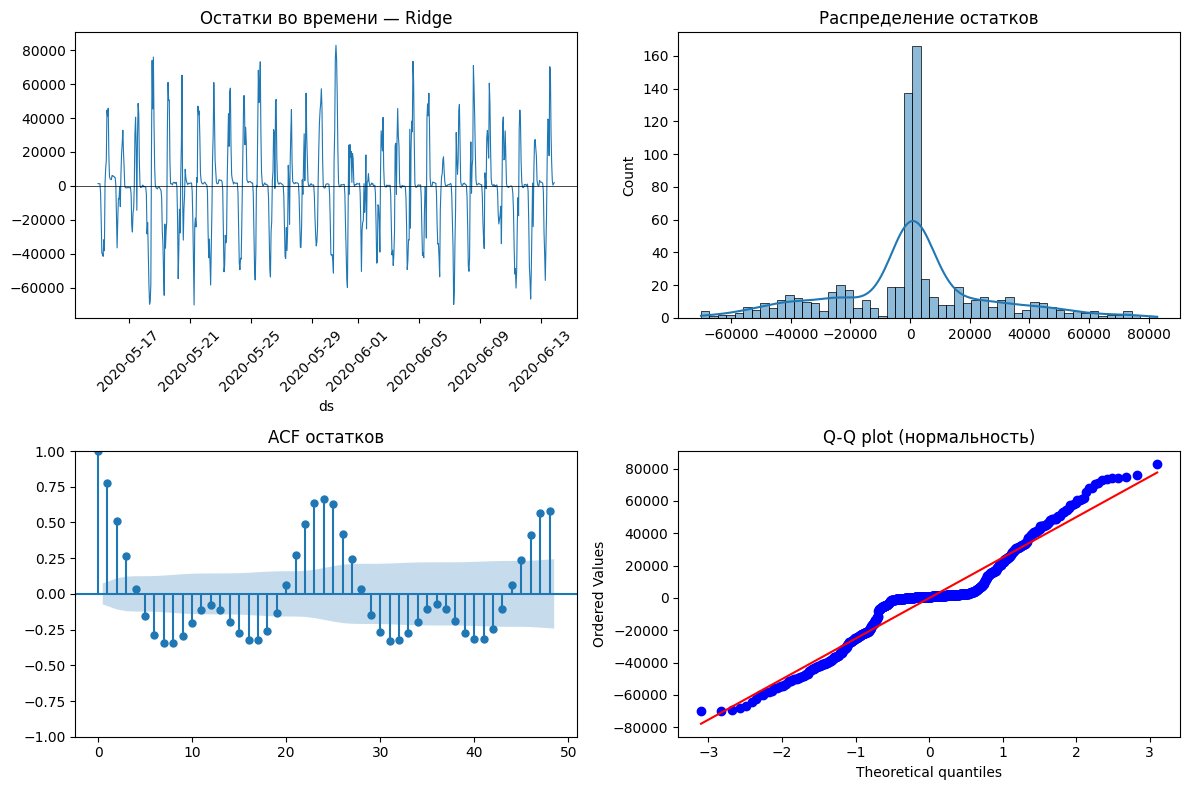

Ljung–Box (Ridge):


,lb_stat,lb_pvalue
24,2208.795302,0.0
48,3991.096551,0.0


In [27]:
ml_all_data = pd.concat([
    residual_data.reset_index(drop=True),
    ml_fitted.drop(['unique_id', 'ds', 'y'], axis=1),
], axis=1)

for m_name in list(mlf.models.keys()):
    d = ml_all_data[['unique_id', 'ds', 'y', m_name]].dropna()
    plot_residual_diagnostics(d['ds'], d['y'], d[m_name], m_name)


Лучшая DL-модель на hold-out: NHITS


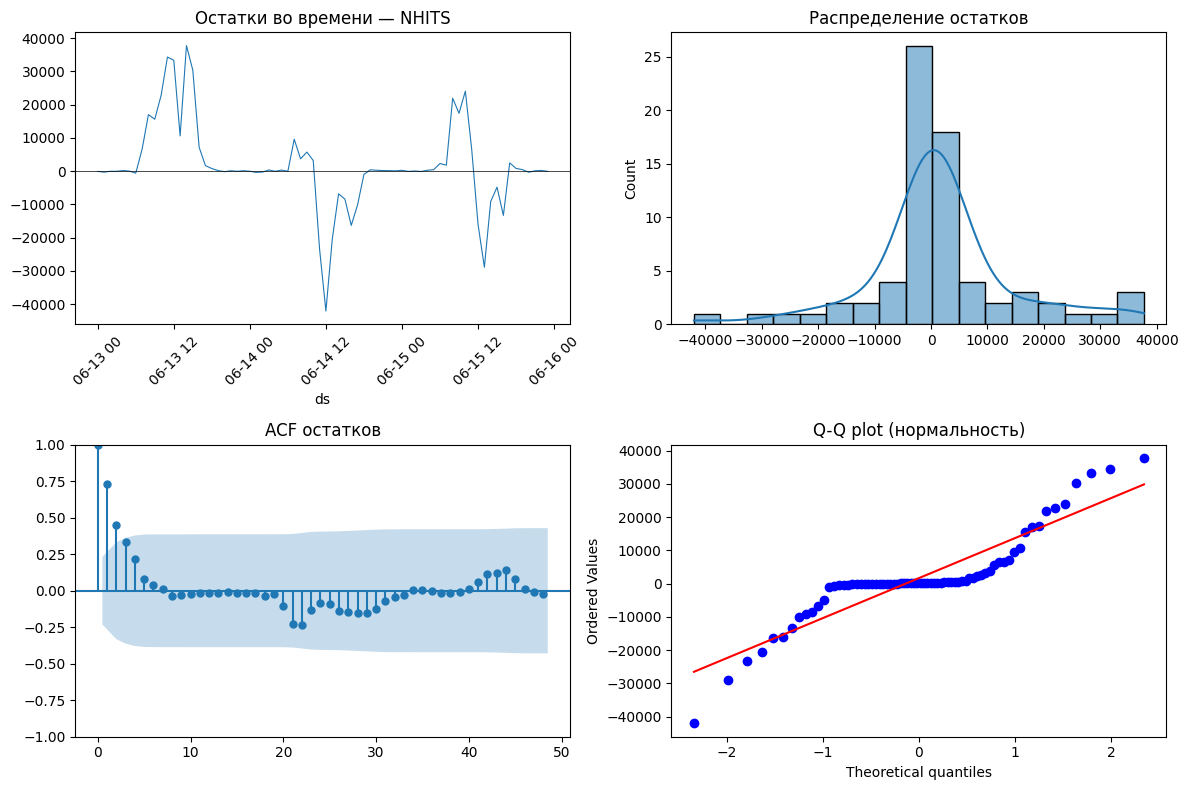

Ljung–Box (NHITS):


,lb_stat,lb_pvalue
24,83.640527,1.583875e-08
48,108.884802,1.257106e-06


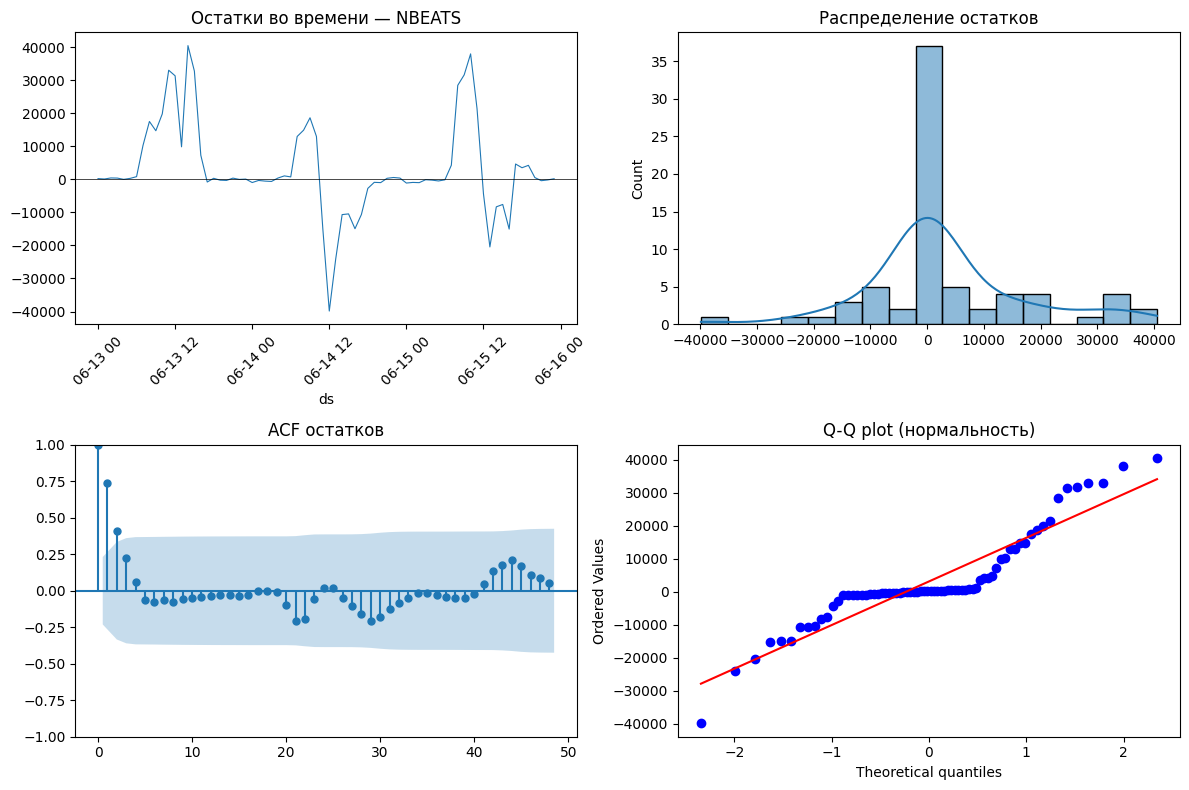

Ljung–Box (NBEATS):


,lb_stat,lb_pvalue
24,70.769109,1.671088e-06
48,117.665667,8.835192e-08


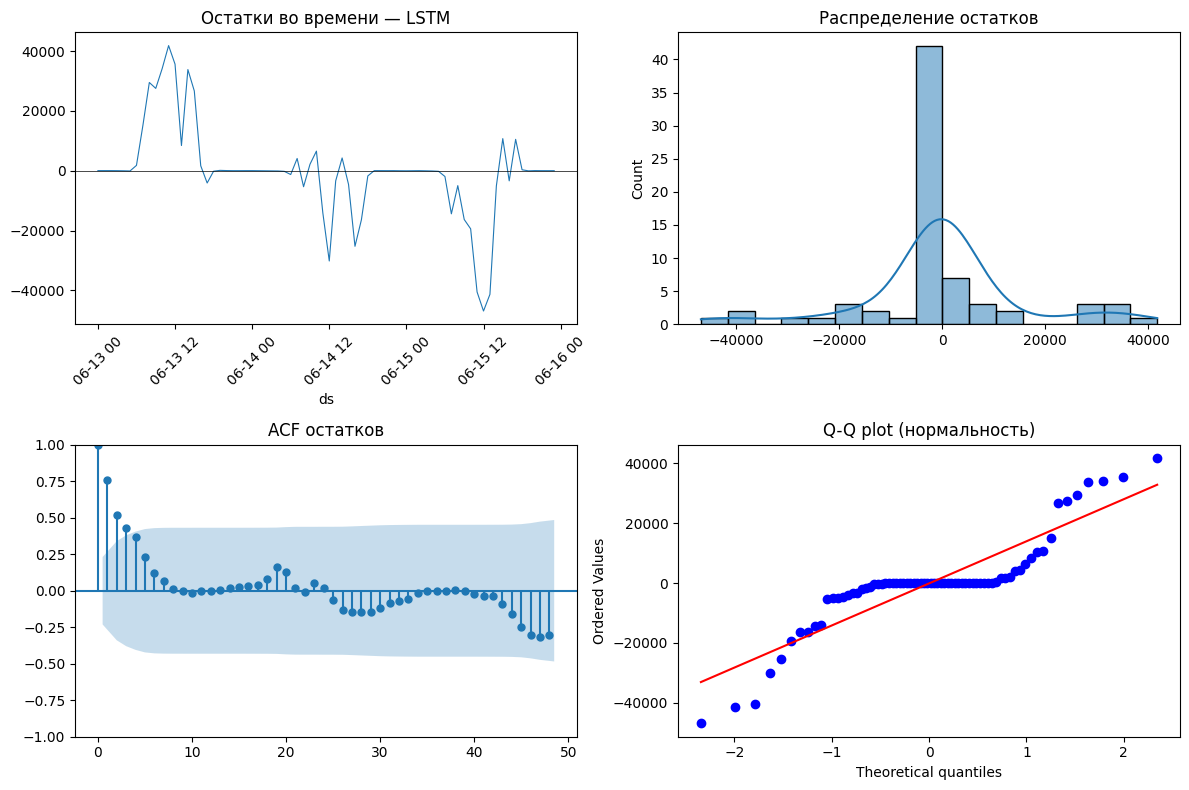

Ljung–Box (LSTM):


,lb_stat,lb_pvalue
24,100.462972,2.504687e-11
48,193.389867,2.365414e-19


In [28]:
dl_holdout = print_metrics(test_data, dl_forecasts, [str(m) for m in dlf.models])
best_dl_name = dl_holdout.index[0]
print(f'Лучшая DL-модель на hold-out: {best_dl_name}')

for m_name in [str(m) for m in dl_cv_models]:
    d = dl_cv[['unique_id', 'ds', 'y', m_name]].dropna()
    plot_residual_diagnostics(d['ds'], d['y'], d[m_name], m_name)
